# 3. Machine Learning for Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
from sklearn.model_selection import train_test_split

%matplotlib inline

## 3.1 Data preparation

In [2]:
data = 'https://github.com/alexeygrigorev/mlbookcamp-code/blob/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [3]:
!wget $data

--2026-06-18 13:00:14--  https://github.com/alexeygrigorev/mlbookcamp-code/blob/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘WA_Fn-UseC_-Telco-Customer-Churn.csv’

WA_Fn-UseC_-Telco-C     [ <=>                ] 228.00K  --.-KB/s    in 0.06s   

2026-06-18 13:00:15 (3.79 MB/s) - ‘WA_Fn-UseC_-Telco-Customer-Churn.csv’ saved [233475]



In [4]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)
for col in categorical_columns:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [7]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [8]:
df.dtypes

,0
customerid,object
gender,object
seniorcitizen,int64
partner,object
dependents,object
tenure,int64
phoneservice,object
multiplelines,object
internetservice,object
onlinesecurity,object


In [9]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')

In [10]:
tc.isnull().sum()

np.int64(11)

In [11]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')

In [12]:
df.totalcharges = df.totalcharges.fillna(0)

In [13]:
df.churn.head()

,churn
0,no
1,no
2,yes
3,no
4,yes


In [14]:
df['churn'] = (df['churn'] == 'yes').astype(int)

## 3.2 Setting Up the Validation Framework

In [15]:
# train_test_split?

In [16]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [17]:
df_train, df_val = train_test_split(df_full_train, test_size=0.2, random_state=1)

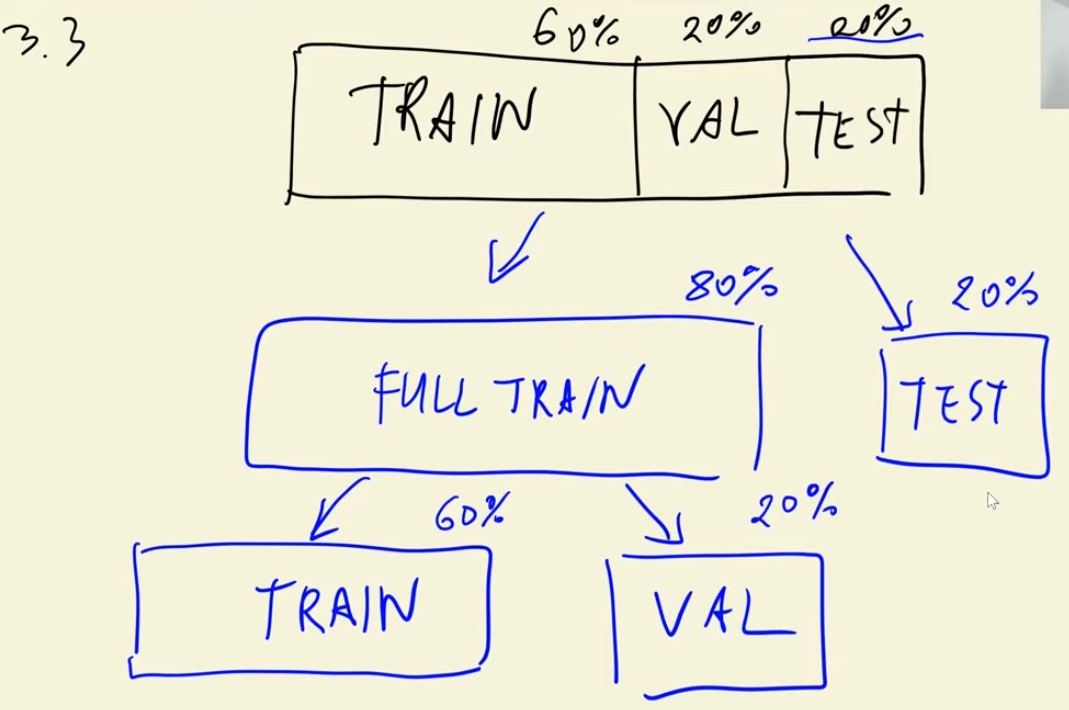

In [18]:
len(df_train), len(df_val), len(df_test)

(4507, 1127, 1409)

In [ ]:
# In-Memory Shuffling, for datasets that fit easily into your machine's RAM
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [ ]:
# Move churn variable into train, val, and test
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [ ]:
# Remove unuse var
del df_train['churn']
del df_val['churn']
del df_test['churn']

## 3.3 EDA

- Check missing values
- Look at the target variable (churn)
- Look at numerical and categorical variables

In [ ]:
# Useful for data analysis
df_full_train = df_full_train.reset_index(drop=True)

In [ ]:
df_full_train.isnull().sum()

,0
customerid,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0
onlinesecurity,0


In [ ]:
# Check the target variabels and distribution
df_full_train.churn.value_counts(normalize=True)

,proportion
churn,
0,0.730032
1,0.269968


In [ ]:
# Show churn rate from the entire dataset
global_churn_rate = df_full_train.churn.mean()
round(global_churn_rate, 2)

np.float64(0.27)

In [ ]:
numerical = ['tenure', 'monthlycharges', 'totalcharges'] # save all numerical variables

In [ ]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [ ]:
categorial = ['gender', 'seniorcitizen', 'partner', 'dependents',
       'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod'] # save all categorical variables

In [ ]:
df_full_train[categorial].nunique()

,0
gender,2
seniorcitizen,2
partner,2
dependents,2
phoneservice,2
multiplelines,3
internetservice,3
onlinesecurity,3
onlinebackup,3
deviceprotection,3


## 3.4 Feature importance: Churn rate and risk ratio

**Churn rate**

In [ ]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [ ]:
# Check the churn rate data within each group
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_female

np.float64(0.27682403433476394)

In [ ]:
churn_female = df_full_train[df_full_train.gender == 'male'].churn.mean()
churn_female

np.float64(0.2632135306553911)

In [ ]:
global_churn = df_full_train.churn.mean()
global_churn

np.float64(0.26996805111821087)

In [ ]:
df_full_train.partner.value_counts()

,count
partner,
no,2932
yes,2702


In [ ]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_partner

np.float64(0.20503330866025166)

In [ ]:
global_churn - churn_partner

np.float64(0.06493474245795922)

In [ ]:
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()
churn_no_partner

np.float64(0.3298090040927694)

In [ ]:
global_churn - churn_no_partner

np.float64(-0.05984095297455855)

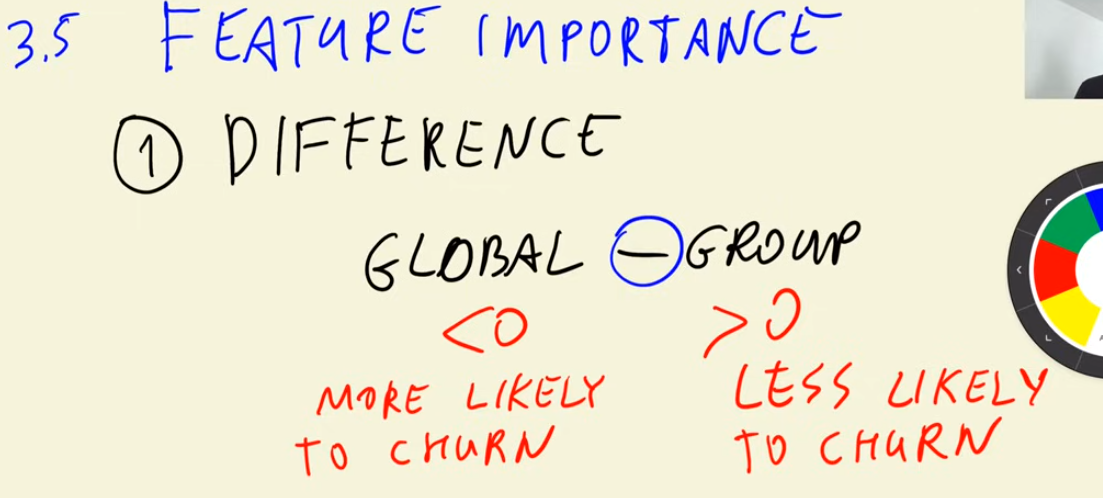

If the different between global and group is higher than zero, than the global churn rate is greater than the group churn rate.
This mean that this group is less likely to churn.
<br>
If the different between global and group is negative or less than zero, than the global churn rate is lower than the group churn rate.
This mean that this group is more likely  to churn.

In [19]:
df_full_train.groupby('gender').churn.agg(['mean', 'count'])

,mean,count
gender,,
female,0.276824,2796
male,0.263214,2838


**Risk ratio**

In [ ]:
churn_partner / global_churn

np.float64(0.7594724924338315)

In [ ]:
churn_no_partner / global_churn

np.float64(1.2216593879412643)

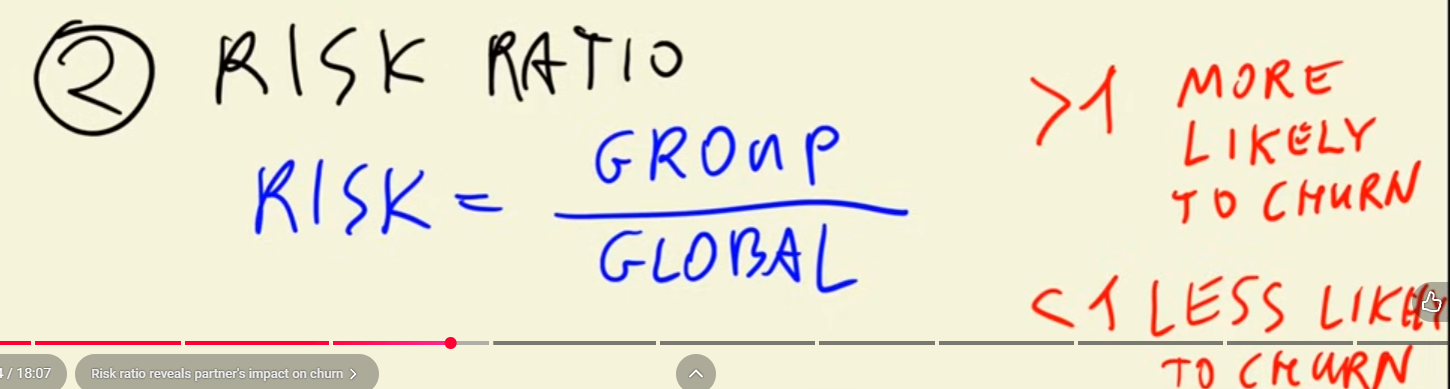

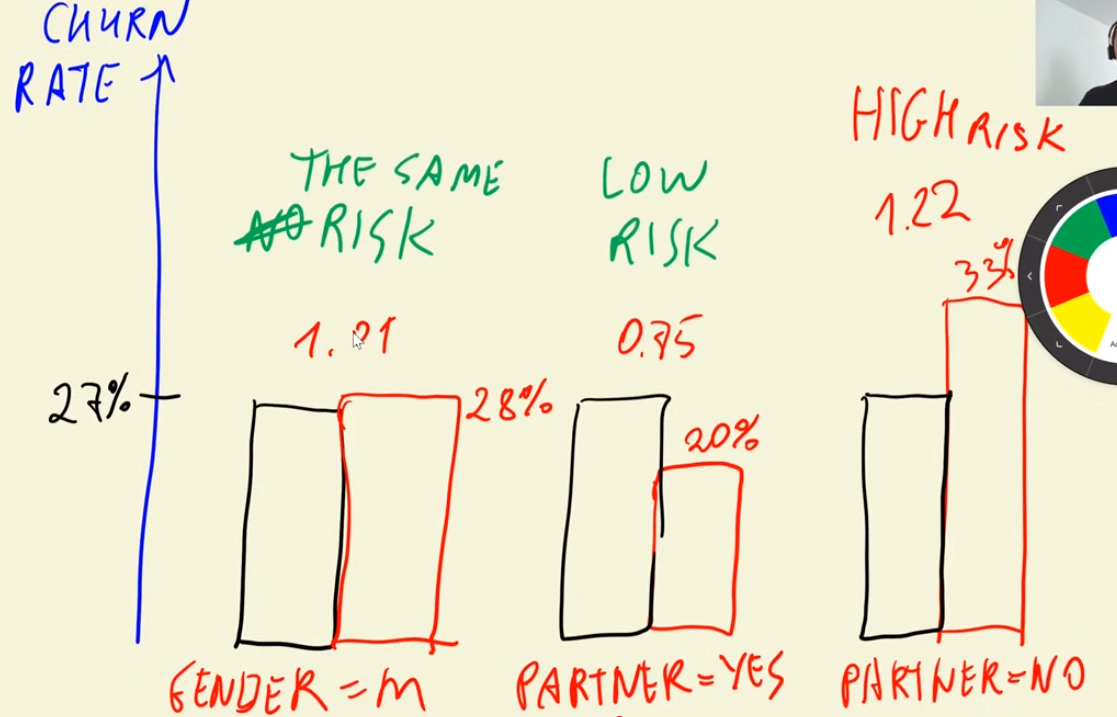

## 3.5 Feature Importance: Mutual Information

Feature importance analysis (part of EDA) - identifying which features affect our target variable
- Churn rate
- Risk ratio
- Mutual information - later

In [ ]:
mutual_info_score(df_full_train.churn, df_full_train.contract)

np.float64(0.0983203874041556)

In [ ]:
mutual_info_score(df_full_train.gender, df_full_train.churn)

np.float64(0.0001174846211139946)

In [ ]:
mutual_info_score(df_full_train.partner, df_full_train.churn)

np.float64(0.009967689095399745)

In [ ]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [ ]:
# Check some important var for train model
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [ ]:
mi = df_full_train[categorial].apply(mutual_info_churn_score)
mi.sort_values(ascending=False) # higher score mean more important

In [ ]:
for c in categorial:
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['dff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean']/  global_churn
    display(df_group)
    print(c)
    print()

,mean,count,dff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980


gender



,mean,count,dff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208


seniorcitizen



,mean,count,dff,risk
partner,,,,
no,0.329809,2932,0.059841,1.221659
yes,0.205033,2702,-0.064935,0.759472


...

contract



,mean,count,dff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560


paperlessbilling



,mean,count,dff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


paymentmethod



## 3.6 Feature Importance: Correlation

In [ ]:
df_full_train.tenure.max()

72

In [ ]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

np.float64(0.3994413407821229)

In [ ]:
df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.17634908339788277)

In [ ]:
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()

np.float64(0.08795411089866156)

In [ ]:
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()

np.float64(0.18340943683409436)

In [ ]:
df_full_train[df_full_train.monthlycharges > 50].churn.mean()

np.float64(0.32499341585462205)

## 3.7 One-hot encoding

Use scikit-learn to encode categorical features

In [ ]:
from sklearn.feature_extraction import DictVectorizer

In [ ]:
# df_train[['gender', 'contract']].iloc[:100]

In [ ]:
# dicts = df_train[['gender', 'contract',  'tenure']].iloc[:100].to_dict(orient='records')

In [ ]:
# dicts[0]

In [ ]:
dv = DictVectorizer(sparse=False)

In [ ]:
# train_dicts = df_train[categorial + numerical].iloc[:100].to_dict(orient='records')

In [ ]:
train_dicts = df_train[categorial + numerical].to_dict(orient='records')

In [ ]:
# dv.fit(train_dicts)

In [ ]:
X_train = dv.fit_transform(train_dicts)

In [ ]:
X_train.shape

(4507, 45)

In [ ]:
val_dict = df_val[categorial + numerical].to_dict(orient='records')

In [ ]:
# dv.get_feature_names()

In [ ]:
# list(dv.transform(train_dicts[:5])[0])

In [ ]:
X_val = dv.transform(val_dict)

## 3.8 Logistic Regression

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
z = np.linspace(-7, 7, 51)

In [ ]:
sigmoid(10000)

np.float64(1.0)

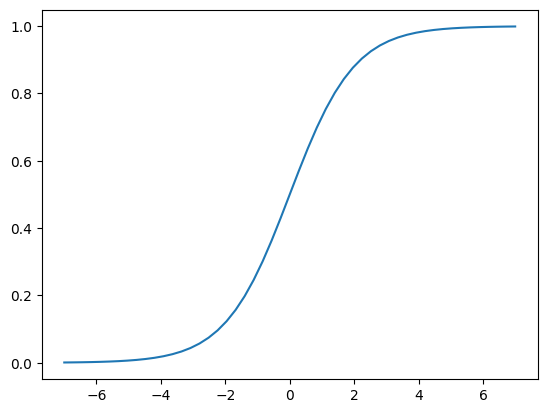

In [ ]:
plt.plot(z, sigmoid(z))

In [ ]:
def linear_regression(xi):
    result = w0

    for j in range(len(w)):
        result = result + xi[j] * w[j]

    result

In [ ]:
def linear_regression(xi):
    result = w0

    for j in range(len(w)):
        result = result + xi[j] * w[j]

    result

## 3.9 Training logistic regression with scikit-learn

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
model.intercept_[0]

np.float64(-0.11799289543738488)

In [ ]:
model.coef_[0].round(3)

array([ 0.583, -0.173, -0.526, -0.025, -0.091,  0.067, -0.106, -0.077,
       -0.046, -0.07 , -0.353,  0.343, -0.106,  0.002, -0.244,  0.154,
       -0.026,  0.058, -0.106, -0.068,  0.243, -0.106, -0.253, -0.223,
        0.107, -0.105, -0.011, -0.116, -0.033,  0.085, -0.051,  0.154,
       -0.27 ,  0.194, -0.094, -0.106,  0.084, -0.049, -0.106,  0.039,
        0.215, -0.106, -0.225, -0.07 ,  0.   ])

In [ ]:
y_pred = model.predict_proba(X_val)[:, 1]

In [ ]:
churn_decision = (y_pred >= 0.5)

In [ ]:
df_val[churn_decision].customerid

,customerid
3,8433-wxgna
8,3440-jpscl
12,7228-omtpn
19,6711-fldfb
24,2612-ranwt
...,...
1114,8740-cryfy
1115,0723-drclg
1117,4195-nzgta
1118,2761-ociax


In [ ]:
(y_val == churn_decision).mean()

np.float64(0.80301685891748)

In [ ]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [ ]:
df_pred

,probability,prediction,actual
0,0.008125,0,0
1,0.205554,0,0
2,0.216355,0,0
3,0.576786,1,1
4,0.209447,0,0
...,...,...,...
1122,0.001354,0,0
1123,0.131603,0,0
1124,0.031953,0,0
1125,0.588925,1,1


In [ ]:
df_pred['correct'] = df_pred.prediction == df_pred.actual

In [ ]:
df_pred.correct.mean()

np.float64(0.80301685891748)

In [ ]:
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 0])

## 3.10 Model Interpretation

In [ ]:
a = [1, 2, 3, 4]
b = 'abcd'

In [ ]:
dict(zip(a, b))

{1: 'a', 2: 'b', 3: 'c', 4: 'd'}

In [ ]:
# dict(zip(dv.get_feature_names(), model.coef_[0].round(3)))

In [ ]:
small = ['contract', 'tenure', 'monthlycharges']

In [ ]:
df_train[small].iloc[:10]

,contract,tenure,monthlycharges
0,one_year,30,19.70
1,month-to-month,23,83.75
2,month-to-month,14,95.80
3,two_year,56,19.70
4,two_year,63,98.00
5,month-to-month,33,80.60
6,month-to-month,2,19.25
7,month-to-month,8,30.45
8,two_year,66,66.10
9,one_year,42,54.75


In [ ]:
dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small =  df_val[small].to_dict(orient='records')

In [ ]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

DictVectorizer(sparse=False)

In [ ]:
# dv_small.get_feature_names()

In [ ]:
X_train_small = dv_small.transform(dicts_train_small)

In [ ]:
model_small = LogisticRegression()
model_small.fit(X_train_small, y_train)

LogisticRegression()

In [ ]:
w0 = model_small.intercept_[0]
w0

np.float64(-2.537777943464722)

In [ ]:
w = model_small.coef_[0]
w.round(3)

array([ 1.011, -0.025, -0.986,  0.028, -0.036])

In [ ]:
# dict(zip(dv_small.get_feature_names(), w.round(3)))

In [ ]:
# sigmoid(-2.7)

In [ ]:
-2.47 + (-0.949) + 30 * 0.027 + 24 * (0.03)

-1.889

In [ ]:
sigmoid(_)

np.float64(0.1313585308484743)

## 3.11 Using the model

In [ ]:
dicts_full_train = df_full_train[categorial + numerical].to_dict(orient='records')

In [ ]:
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

In [ ]:
y_full_train = df_full_train.churn.values

In [ ]:
model = LogisticRegression()
model.fit(X_full_train, y_full_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
dicts_test = df_test[categorial + numerical].to_dict(orient='records')

In [ ]:
X_test = dv.transform(dicts_test)

In [ ]:
dicts_test[10]

{'gender': 'male',
 'seniorcitizen': 1,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'no',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'no',
 'onlinebackup': 'yes',
 'deviceprotection': 'no',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month-to-month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'mailed_check',
 'tenure': 32,
 'monthlycharges': 93.95,
 'totalcharges': 2861.45}

In [ ]:
y_pred = model.predict_proba(X_test)[:,1]

In [ ]:
churn_decision = (y_pred >= 0.5)

In [ ]:
(churn_decision == y_test).mean()

np.float64(0.8140525195173882)

In [ ]:
y_test

array([0, 0, 0, ..., 0, 0, 1])

In [ ]:
customer = dicts_test[-1]
customer

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'no',
 'deviceprotection': 'yes',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month-to-month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 17,
 'monthlycharges': 104.2,
 'totalcharges': 1743.5}

In [ ]:
X_small = dv.transform([customer])

In [ ]:
model.predict_proba(X_small)[0,1]

np.float64(0.6613470087309817)

In [ ]:
y_test[10]

np.int64(0)